# Tutorial 5: SurEau-Medlyn Basic run 


## Load modules

In [ ]:
from siuba import *
from plotnine import *
from plotnine import *
import numpy as np, pandas as pd
from itables import to_html_datatable
from IPython.display import HTML, display

In [ ]:
from plant_hydraulics.run_sureau import run_sureau
from plant_hydraulics.sureau_climate import *  
from plant_hydraulics.utils import potential_PAR
from plant_hydraulics.parameter_classes import (
    SurEauVegetationParams,
    SurEauSoilParams,
    SurEauModelOptions,
)

from plant_hydraulics.utils import (
    load_example_data,
)

# Object initialization

In [ ]:

# Model options
opts = SurEauModelOptions(
    
    # Richmond
    latitude=-33.5996,
    
    # Meters above sea level
    elevation = 24,
    
    # net radiation model: "Linacre" (only option currently)
    Rn_formulation="Linacre",
    
    # PET model: "PT" (Priestley-Taylor) or "PM" (Penman-Monteith)
    ETP_formulation="PT",
    
    # True → forces a fixed doy=116 (sunny day template)
    constant_climate = False,
    # which hours to output (0–23 → full day)
    time_steps=np.arange(24),
    
    # Print progress to console
    print_progress=True,
    
    year_start=2016,
    year_end=2016
)

In [ ]:
# Vegetation parameters
veg_params = SurEauVegetationParams()

# Leaf area index (m²/m²). Higher = more transpiration.
veg_params.LAI_max = 2.5     
  
veg_params.foliage = "Evergreen"  

veg_params.transpiration_model = "Medlyn"

veg_params.g_crown0 = 1e4  


# Params from Drake 
veg_params.vcmax25 = 34
veg_params.vcmaxha = 51780
veg_params.vcmaxhd = 2e5
veg_params.vcmaxse = 640

veg_params.jmax25 = 60
veg_params.jmaxha = 21640
veg_params.jmaxhd = 2e5
veg_params.jmaxse = 633

veg_params.g1_medlyn = 2.9
veg_params.g0_medlyn = 0.003

# ψ at 50% loss of leaf conductance (MPa) 
veg_params.P50_VC_leaf = -3.89

# ψ at 50% loss of stem conductance (MPa)   
veg_params.P50_VC_stem = -3.89

# Steepness of vulnerability sigmoid (%/MPa)   
veg_params.slope_VC_leaf = 50   

# ψ at 12% stomatal closure (MPa)
veg_params.P12_gs = -2.18

# ψ at 88% stomatal closure (MPa)       
veg_params.P88_gs = -4       

# Whole-plant conductance (mmol/m²/s/MPa)
veg_params.k_plant_init = 100  

# At 20°C (mmol/m²/s)
veg_params.gmin20 = 4.0

# Temperature where cuticle melts (°C)         
veg_params.TPhase_gmin = 39

veg_params.Q10_1_gmin = 1
# Q10 above TPhase    
veg_params.Q10_2_gmin = 3
veg_params.gmin20 = 3



In [ ]:
soil_params = SurEauSoilParams()

## Climate

SurEau takes daily climatic data and then creates a hourly dataset 

In [ ]:

climate_df = load_example_data("sureau_medlyn_daily_climate.csv", sep=",")
#climate_df["DATE"] = pd.to_datetime(climate_df["DATE"], format="%d/%m/%Y").dt.strftime("%Y-%m-%d")
html_str = to_html_datatable(climate_df)
display(HTML(html_str))

Loading ITables v2.8.1 from the internet... (need help?)


### Explore climatic data

In [ ]:
hourly_data_from_daily = []
for each_day in range(len(climate_df)):
    
    # Get date 
    date_str = str(climate_df.iloc[each_day]["DATE"])              
   
    # Calculate climate for that day
    clim = new_climate_day(climate_df, date_str)
    
    # Compute PET for that day
    clim = compute_Rn_and_ETP(clim, veg_params, opts)
    
    # Create hourly climate from daily conditions     
    ch   = new_climate_hourly(clim, opts, veg_params)    
    
    #Show data in ch
    #print("ch.__dict__ keys:", list(vars(ch).keys()))
    
    # Put everything into frame that works for Sureau
    hourly_data_from_daily.append(pd.DataFrame({
        "Doy":    int(climate_df.iloc[each_day]["DOY"]),
        "hour":   np.asarray(ch.time, float),
        "RG":     np.asarray(ch.RG, float), 
        "RH":     np.asarray(ch.RH_air_mean, float),           
        "PAR_d":  np.asarray(ch.PAR, float),
        "Tair_d": np.asarray(ch.T_air_mean, float),
        "VPD_d":  np.asarray(ch.VPD, float),
    }))
hourly_data_from_daily = pd.concat(hourly_data_from_daily, ignore_index=True)

## Run the model

In [ ]:
results = run_sureau(
    climate_df=climate_df,
    veg_params=veg_params,
    soil_params=soil_params,
    opts=opts,
    
    # Set True to keep deepest layer at field capacity
    deep_water=False,  
)


Year 2016 Day 305
Year 2016 Day 306
Year 2016 Day 307
Year 2016 Day 308
Year 2016 complete. 


In [ ]:
results = results >> filter(_.PAR > 100) >> mutate(e_total = "E_lim" + "E_min")

In [ ]:
html_str = to_html_datatable(results)
display(HTML(html_str))

Loading ITables v2.8.1 from the internet... (need help?)


##  Plot results 

In [ ]:
raw_chamber_data = load_example_data("heatwave_raw_data_drake.csv", sep=",")

# Filter data as Drake did
raw_chamber_data = raw_chamber_data >> filter(_.PAR > 500)

In [ ]:
model_predictions = load_example_data("photosyneb_predictions_heatwave_data_drake.csv", sep=",")
model_predictions = model_predictions >> filter(_.PPFD > 500)
model_predictions

,Ci,ALEAF,GS,ELEAF,Ac,Aj,Ap,Rd,VPD,Tleaf,...,lambdaET,gw,Gbh,H2,Tleaf2,VPDleaf,Tair,Wind,failed,Tdiff
42,322.985428,8.228189,0.167747,0.612737,8.896392,9.177356,1000,0.642540,0.261311,19.497460,...,27.103965,0.164247,7.322979,204.099826,19.364029,0.410459,18.411248,8,False,1.086212
43,322.960106,8.384290,0.170873,0.694608,9.200538,9.518517,1000,0.791669,0.279709,22.697012,...,30.636983,0.167213,7.262786,207.356211,22.379843,0.489625,21.403838,8,False,1.293175
45,322.960375,8.391355,0.171014,1.102912,9.176541,9.690400,1000,0.769343,0.436916,22.258472,...,48.665590,0.167353,7.271810,345.896614,22.611524,0.638882,20.985444,8,False,1.273028
46,322.975572,8.301525,0.169216,1.142399,9.224982,9.920835,1000,0.911465,0.427226,24.857125,...,50.286751,0.165604,7.217356,351.131373,25.141228,0.677616,23.478084,8,False,1.379041
47,322.964842,8.364277,0.170472,1.050069,9.100557,9.629556,1000,0.721112,0.363751,21.265984,...,46.376062,0.166844,7.291882,424.367094,22.032254,0.547976,20.042771,8,False,1.223213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300,281.222199,5.603939,0.074074,1.369398,7.000423,9.056541,1000,1.394104,1.689198,31.371573,...,59.931598,0.073362,7.104419,241.282555,30.596455,2.172908,29.435446,8,False,1.936127
2301,286.980594,6.806531,0.094554,1.455413,7.947313,9.378311,1000,1.136387,1.427771,28.238194,...,63.879751,0.093408,7.166569,215.472307,27.498411,1.806333,26.470588,8,False,1.767606
2302,288.554588,6.887815,0.097035,1.401016,8.017654,9.311475,1000,1.124896,1.369254,28.082395,...,61.500631,0.095828,7.169230,173.932160,27.158550,1.741888,26.329185,8,False,1.753210
2303,282.295489,5.789133,0.077220,1.336238,7.151336,8.997573,1000,1.359439,1.637316,30.985571,...,58.500985,0.076448,7.111856,181.942481,29.947364,2.106332,29.072804,8,False,1.912767


/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 8 rows containing missing values.


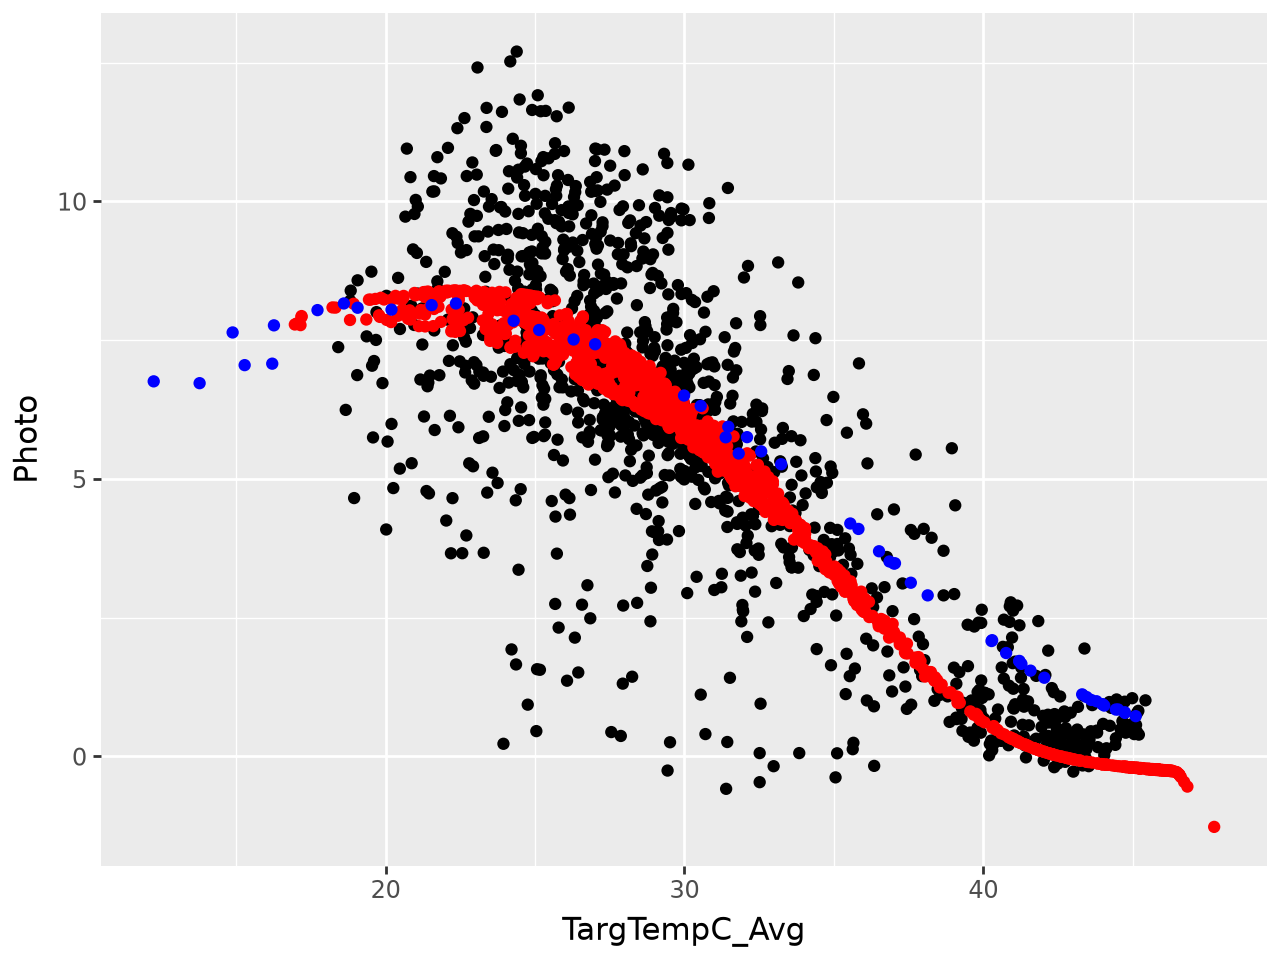

In [ ]:
ggplot() + geom_point(raw_chamber_data, aes(x = 'TargTempC_Avg', y = 'Photo')) + \
    geom_point(model_predictions, aes(x="Tleaf", y = "ALEAF"),  color='red') + \
    geom_point(results, aes(x="leaf_temperature", y = "An"),  color='blue') 
    
     


/var/home/ecamo19/Documents/projects/modeling/plant_hydraulics/.pixi/envs/default/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 18 rows containing missing values.


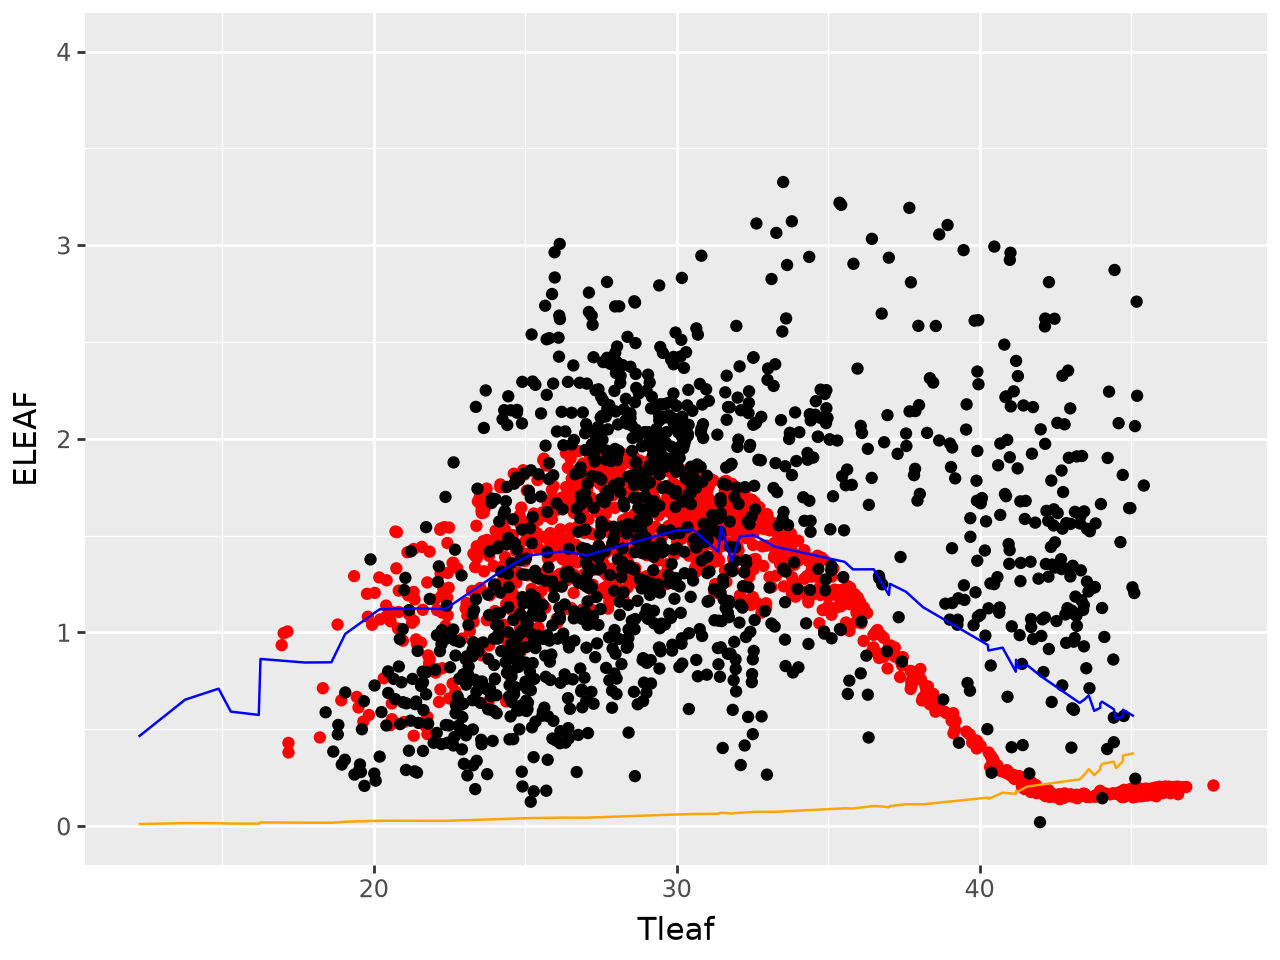

In [ ]:
ggplot() + \
    geom_point(model_predictions, aes(x="Tleaf", y = "ELEAF"),  color='red') + \
    geom_point(raw_chamber_data, aes(x = 'TargTempC_Avg', y = 'Trans')) + \
    geom_line(results, aes(x="leaf_temperature", y = "E_lim"),  color='blue') + \
    geom_line(results, aes(x="leaf_temperature", y = "E_min"),  color='orange') + \
    ylim(0,4) 
        

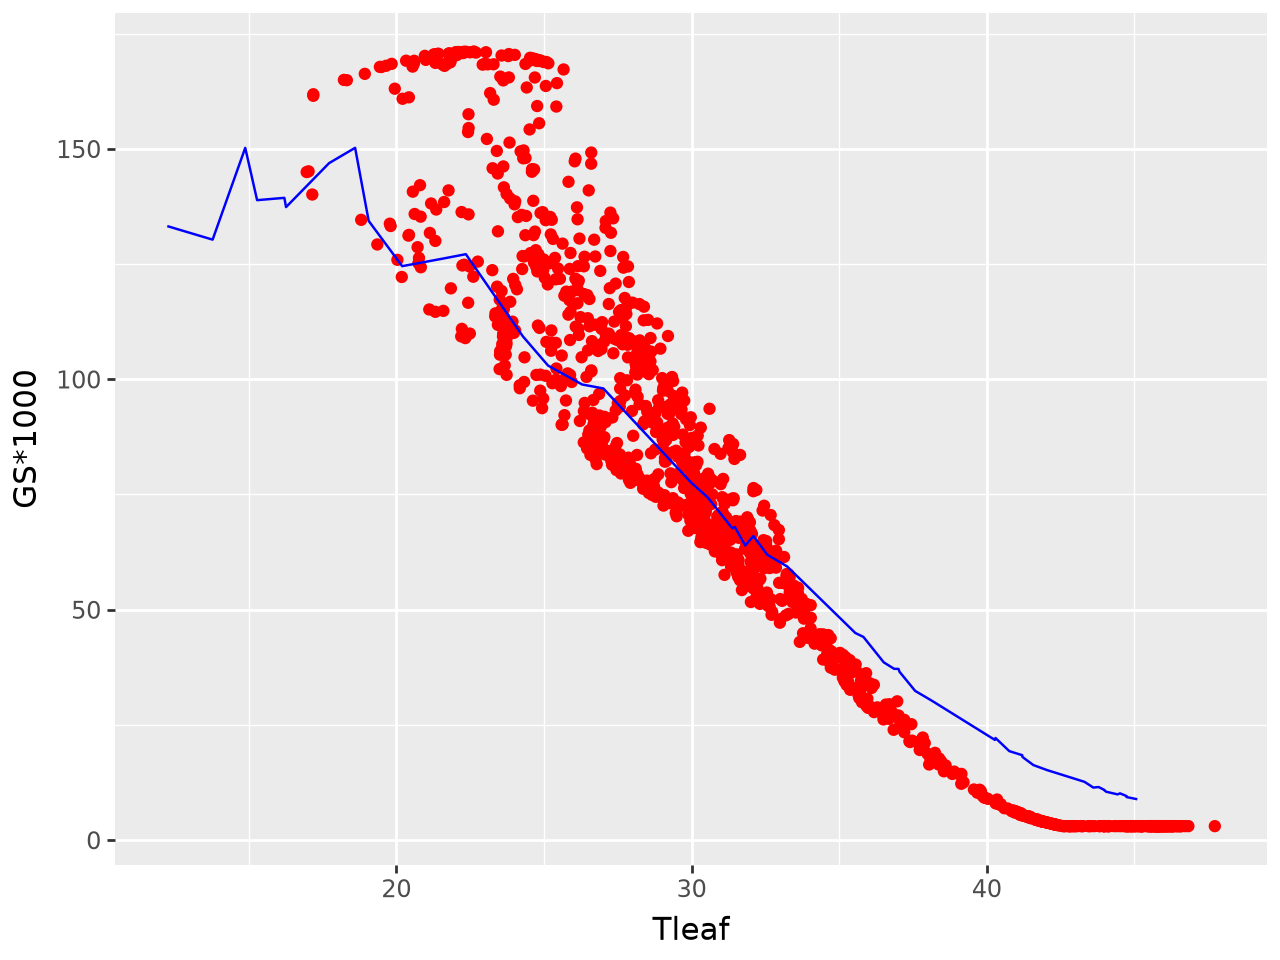

In [ ]:
ggplot() + \
    geom_point(model_predictions, aes(x="Tleaf", y = "GS*1000"),  color='red') +  \
    geom_line(results, aes(x="leaf_temperature", y = "gs_lim"),  color='blue') \
    #geom_point(raw_chamber_data, aes(x = 'TargTempC_Avg', y = 'Trans')) + \
    #geom_line(results, aes(x="leaf_temperature", y = "E_min"),  color='orange') + \
    #ylim(0,4) 